## Week 9 Independent Lab- Winston Caton

In [1]:
# load modules
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts # for QQ plot
from scipy.stats import pearsonr # correlation p-values
from sklearn.linear_model import LinearRegression # regression output
import statsmodels.formula.api as smf # ols regression

os.chdir("c:\\Users\\winst\\OneDrive\\Desktop\\Python 2\\Week9\\week9labs\\data")  # add your filepath within the quotes
os.getcwd()  # confirm change

'c:\\Users\\winst\\OneDrive\\Desktop\\Python 2\\Week9\\week9labs\\data'

In [11]:
ect = pd.read_csv("ect_data.txt", sep='\t')
ect.dtypes

attitude1_01    int64
attitude1_02    int64
attitude1_03    int64
attitude1_04    int64
intent1_01      int64
intent1_02      int64
intent1_03      int64
intent1_04      int64
peruse01        int64
peruse02        int64
peruse03        int64
peruse04        int64
satis01         int64
satis02         int64
satis03         int64
satis04         int64
dtype: object

In [8]:
## Create our multiple regression model

model = LinearRegression(fit_intercept=True)
model.fit(ect[['attitude1_01', 'peruse01', 'satis01', 'satis04', 'attitude1_03']], ect['intent1_01'])

LinearRegression()

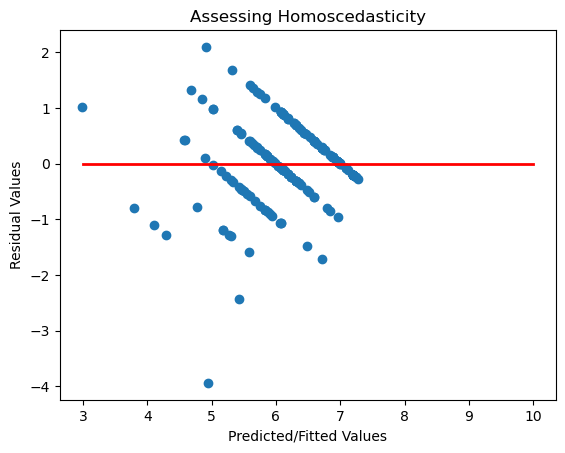

In [25]:
## Assess Linearity- Assessment of homoscedasticity.
## By looking at the residuals and assessing for randomness of the residuals, we can verify our assumption around linearity.

model2 = smf.ols('intent1_01 ~ attitude1_01 + peruse01 + satis01 + satis04 + attitude1_03', ect).fit()

# assess homoscedasticity
plt.scatter(model2.fittedvalues, model2.resid)
plt.xlabel('Predicted/Fitted Values')
plt.ylabel('Residual Values')
plt.title('Assessing Homoscedasticity')
plt.plot([3, 10],[0, 0], 'red', lw=2)   # add red horizontal line
plt.show()


We can clearly see that these residuals are not random, as they array in several straight lines so we can reject the validity of the linearity assumption for this model.

In [14]:
## Assess for Collinearity

# use the sklearn library for regression 
#'intent1_01 ~ attitude1_01 + peruse01 + satis01 + satis04 + attitude1_03'
model2 = LinearRegression(fit_intercept=True)
model2.fit(ect[['attitude1_01', 'peruse01', 'satis01', 'satis04', 'attitude1_03']], ect.intent1_01)

# calculate VIF for attitude1_01
model2.fit(ect[['peruse01', 'satis01', 'satis04', 'attitude1_03']], ect.attitude1_01)
vif1 = 1/(1 - model2.score(ect[['peruse01', 'satis01', 'satis04', 'attitude1_03']], ect.attitude1_01))

# calculate VIF for peruse01
model2.fit(ect[['attitude1_01', 'satis01', 'satis04', 'attitude1_03']], ect.peruse01)
vif2 = 1/(1 - model2.score(ect[['attitude1_01', 'satis01', 'satis04', 'attitude1_03']], ect.peruse01))

# calculate VIF for satis01
model2.fit(ect[['attitude1_01', 'peruse01', 'satis04', 'attitude1_03']], ect.satis01)
vif3 = 1/(1 - model2.score(ect[['attitude1_01', 'peruse01', 'satis04', 'attitude1_03']], ect.satis01))

# calculate VIF for satis04
model2.fit(ect[['attitude1_01', 'peruse01', 'satis01', 'attitude1_03']], ect.satis04)
vif4 = 1/(1 - model2.score(ect[['attitude1_01', 'peruse01', 'satis01', 'attitude1_03']], ect.satis04))

# calculate VIF for attitude1_03
model2.fit(ect[['attitude1_01', 'peruse01', 'satis01', 'satis04']], ect.attitude1_03)
vif5 = 1/(1 - model2.score(ect[['attitude1_01', 'peruse01', 'satis01', 'satis04']], ect.attitude1_03))

# output VIF scores
print('VIF attitude1_01: ', vif1,
        '\nVIF wperuse01: ', vif2,
        '\nVIF satis01: ', vif3,
        '\nVIF satis04: ',vif4,
        '\nVIF attitude1_03: ',vif5)

VIF attitude1_01:  2.904489315980744 
VIF wperuse01:  1.5339985170730488 
VIF satis01:  2.842934016617241 
VIF satis04:  2.710994509000799 
VIF attitude1_03:  2.459596909206896


These VIF scores are all below 5, which suggests that we can tentatively accept our assumption of colinearity.

In [18]:
pearsonr(ect.attitude1_01, ect.intent1_01)

PearsonRResult(statistic=0.6663562202246993, pvalue=3.6154224826027544e-27)

In [19]:
pearsonr(ect.peruse01, ect.intent1_01)

PearsonRResult(statistic=0.5666422098085826, pvalue=1.8194427998723153e-18)

In [20]:
pearsonr(ect.satis01, ect.intent1_01)

PearsonRResult(statistic=0.545688440252472, pvalue=5.425059701904438e-17)

In [21]:
pearsonr(ect.satis04, ect.intent1_01)

PearsonRResult(statistic=0.49419156782544826, pvalue=8.946679615710639e-14)

In [22]:
pearsonr(ect.attitude1_01, ect.intent1_01)

PearsonRResult(statistic=0.6663562202246993, pvalue=3.6154224826027544e-27)

These very small p values suggest that our variables are not independent, and that in fact they are correlated.  We must reject our assumption that the variables are independent because of this.

((array([-2.70235077, -2.39300644, -2.21670641, -2.09047253, -1.99075721,
         -1.90762425, -1.83590295, -1.77254445, -1.71559368, -1.66371874,
         -1.61596971, -1.57164427, -1.53020786, -1.49124379, -1.45442067,
         -1.41947039, -1.38617282, -1.35434495, -1.32383285, -1.29450578,
         -1.26625169, -1.2389738 , -1.21258791, -1.18702027, -1.1622059 ,
         -1.13808725, -1.11461308, -1.09173755, -1.06941949, -1.04762177,
         -1.02631079, -1.005456  , -0.98502958, -0.96500611, -0.94536226,
         -0.92607659, -0.90712937, -0.88850233, -0.87017859, -0.85214246,
         -0.83437937, -0.81687572, -0.79961884, -0.78259687, -0.76579869,
         -0.74921388, -0.73283263, -0.71664571, -0.70064443, -0.68482057,
         -0.66916635, -0.65367443, -0.63833783, -0.62314992, -0.60810442,
         -0.59319534, -0.57841696, -0.56376385, -0.5492308 , -0.53481284,
         -0.52050522, -0.50630336, -0.49220289, -0.47819962, -0.4642895 ,
         -0.45046865, -0.43673331, -0.

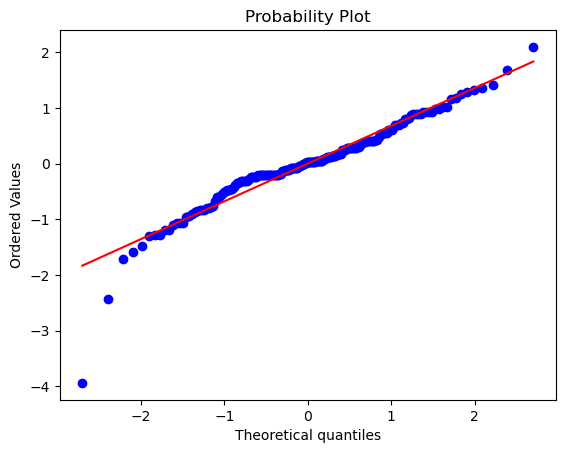

In [26]:
## Assess for Normality using QQ plot

sts.probplot(model2.resid, dist="norm", plot=plt)

In [27]:
## Assess Normality with Shapiro Wilk test

sts.shapiro(ect.intent1_01)

ShapiroResult(statistic=0.7556569933609888, pvalue=5.857737519248959e-17)

The QQ plot looks mostly to follow the best fit line, so the data is acceptably normal for that test.  But the results of the Shapiro Wilk test with the low p value indicates that we have significance here, and the test should result in non significance, so we must therefore reject the assumption of normality.  We don't have a model that meets the assumptions that are needed to have a model that accurately predicts our dependent variable.

In [28]:
## Assess Model's F-test and T-Tests

model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             intent1_01   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                     44.36
Date:                Thu, 01 May 2025   Prob (F-statistic):           2.00e-30
Time:                        17:59:58   Log-Likelihood:                -212.33
No. Observations:                 201   AIC:                             436.7
Df Residuals:                     195   BIC:                             456.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.9736      0.357      2.726      0.007       0.269       1.678
attitude1_01     0.4406      0.091      4.843      0.000       0.261       0.620
peruse01         0.2471      0.058      4.297      0.000       0.134       0.360
satis01          0.1215      0.075      1.614      0.108      -0.027       0.270
satis04          0.1183      0.075      1.573      0.117      -0.030       0.267
attitude1_03    -0.0375      0.073     -0.513      0.609      -0.182       0.107
==============================================================================
Omnibus:                       55.478   Durbin-Watson:                   1.908
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              246.871
Skew:                          -0.979   Prob(JB):                     2.47e-54
Kurtosis:                       8.064   Cond. No.                         93.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The F Test value is 44.36 with a corresponding p value of 2.00 e-30 or essentially zero.  The T-tests values are as follows: attitude1_01 t of 4.843 with a p value of 0, peruse01 t of 4.297 with a p value of 0, satis01 t of 1.614 with a p value of .108, satis04 t of 1.573 with a p value of .117 and attitude1_03 t value of -.513 with a p value of .609.

So due to our low p value on the F-test, we have a very significant model.  Both attitude1_001 and peruse01 are strongly significant predictor variables.  The other variables in the model don't appear to be significant however.  Unfortunately, the model did not validate our assumptions needed for a multiple regression model, so unsure if we have a very good model overall, but it is statistically significant in predicting our response variable.

Attitude1_001 and peruse01 are the two variables that are statistically significant based on their t test and low p values.  This is intuitive, as we can see that an individual's attitudes as tracked in Attitude1_001 and perceived usefulness with a system as captured in peruse01 are the dominant factors that impact an individuals intention to use the system, and that other variables we examined had less impact on the intent to use the system (satisfaction and attitude1_03).

## The formula for our multiple regression model

Dependent Variable = Intercept + Variable1(Coef1) + Variable2(Coef2) ....

Intent1_01 = .9736 + .4406(attitude1_01) + .2471(peruse01) + .1215(satis01) + .1183(satis04) - .0375(attitude1_03)

We can see here that the larger coefficients associated with our more significant variables attitude1_01 and peruse01 have a larger impact on our dependent variable than the smaller coefficients associated with the last 3 variables in the equation.  Attitude1_03 having a negative coefficient will actually show a very slight inverse relationship to Intent1_01.